# Warm-Started Joint Bayesian Operator Inference: Compressible Euler

**Strategy**: Initialise GP hyperparameters from MLE and operator O from least-squares,
then refine jointly via SVI so that the GP and operator inform each other.

This avoids the null-basin problem: the optimiser starts in the correct basin,
so the ODE constraint reinforces (rather than corrupts) the GP fit.

In [15]:
import sys
sys.path.insert(0, '../..')

import numpy as np
import jax
import jax.numpy as jnp
import opinf
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, Predictive, autoguide
from numpyro.infer.initialization import init_to_value
from numpyro.optim import Adam, ClippedAdam
from jax import random
import time

from core import (
    generate_trajectory,
    JaxCompatibleModel,
    compute_gp_derivatives,
    compute_derivatives_fourth_order,
    generate_rom_predictions,
    DataScaler,
    extract_gp_posterior,
    extract_derivative_posterior,
    gp_based_opinf_baseline,
    rbf_eval,
    SVIResult,
)
from core.bayesian_opinf import (
    fit_gp_hyperparameters_mle,
    _find_operator_samples,
)

sys.path.insert(0, '../euler')
import config
from config import Basis

numpyro.set_platform('cpu')
numpyro.set_host_device_count(4)

np.random.seed(42)
rng_key = random.PRNGKey(42)

In [16]:
# === EXPERIMENT CONFIGURATION ===
OPERATORS = "cAH"
IVP_METHOD = "RK45"
NUM_MODES = 6

# Data generation
TRAINING_SPAN = (0, 0.08)
PREDICTION_SPAN = (0, config.time_domain[-1])
NUM_SAMPLES = 250
NOISE_LEVEL = 0.15
NUM_EVAL_POINTS = 400

# Data scaling
USE_SCALED_DATA = False

# Inference settings
GUIDE = autoguide.AutoNormal
VERBOSE = True

# Hyperparameters
GAMMA = 5e-1      # Operator prior scale (~L2 reg of 1/γ²≈0.11, comparable to baseline)
GAMMA2 = 1e1     # ODE constraint slack

# GP hyperparameter priors (LogNormal) — centred on MLE values (set in Stage 1)
GP_LENGTHSCALE_PRIOR_SCALE = 0.5
GP_VARIANCE_PRIOR_SCALE = 0.5
GP_NOISE_PRIOR_SCALE = 0.25

# ODE constraint slack — hierarchical prior
LEARN_GAMMA2 = True
GAMMA2_PRIOR_LOC = None
GAMMA2_PRIOR_SCALE = 1e-1

# === JOINT SVI CONFIGURATION ===
NUM_SVI_STEPS = 10000
LEARNING_RATE = 1e-3
NUM_POSTERIOR_SAMPLES = 1000

# Plotting
NUM_REGRESSION_POINTS = 400

## 1. Generate Training Data

In [17]:
(fom, time_domain_full, true_states, time_sampled, snapshots_sampled) = \
    generate_trajectory(config, config.time_domain, TRAINING_SPAN, NUM_SAMPLES, NOISE_LEVEL)

print(f"Full time domain: {time_domain_full.shape}")
print(f"Sampled times: {time_sampled.shape}")
print(f"Training span: [{TRAINING_SPAN[0]:.4f}, {TRAINING_SPAN[1]:.4f}]")
print(f"Prediction span: [{PREDICTION_SPAN[0]:.4f}, {PREDICTION_SPAN[1]:.4f}]")

generating training data...done in 0.98 s.
Full time domain: (401,)
Sampled times: (250,)
Training span: [0.0000, 0.0800]
Prediction span: [0.0000, 0.1500]


In [18]:
basis = Basis(num_vectors=NUM_MODES)
basis.fit(snapshots_sampled)

snapshots_comp_sampled = basis.compress(snapshots_sampled)
print(f"Compressed shape: {snapshots_comp_sampled.shape}")
print(f"Cumulative energy: {basis.cumulative_energy:.4%}")

# Evaluation time domains
time_domain_eval_training = np.linspace(TRAINING_SPAN[0], TRAINING_SPAN[1], NUM_REGRESSION_POINTS)
time_domain_eval_prediction = np.linspace(PREDICTION_SPAN[0], PREDICTION_SPAN[1], NUM_REGRESSION_POINTS)
full_states_compressed = basis.compress(true_states)

Compressed shape: (6, 250)
Cumulative energy: 26.6008%


In [19]:
if USE_SCALED_DATA:
    data_scaler = DataScaler(num_modes=NUM_MODES)
    data_scaler.fit(snapshots_comp_sampled)
    training_data = data_scaler.transform(snapshots_comp_sampled)
    print(f"Scaling enabled: {data_scaler}")
else:
    data_scaler = None
    training_data = snapshots_comp_sampled
    print("Scaling disabled: using raw POD coefficients")

Scaling disabled: using raw POD coefficients


## 2. Build ROM Structure

In [20]:
rom = opinf.ROM(
    basis=basis,
    ddt_estimator=opinf.ddt.NonuniformFiniteDifferencer(time_sampled),
    model=JaxCompatibleModel(operators=OPERATORS, solver=opinf.lstsq.L2Solver(regularizer=1e0))
)
rom.fit(states=snapshots_sampled)
print(f"Operator shape: {rom.model.operator_matrix.shape}")

Operator shape: (6, 28)


## 3. Stage 1: MLE GP Warm Start

Fit GP hyperparameters (ℓ, σ², ν) independently per mode via maximum marginal likelihood.
This gives us a reliable starting point that avoids the null basin.

In [21]:
# Fit MLE GPs on the (possibly scaled) training data
mle_Ls, mle_Vs, mle_Ns, gp_models = fit_gp_hyperparameters_mle(
    time_domain=time_sampled,
    snapshots=training_data,
    verbose=True,
)

print(f"\nMLE GP hyperparameters:")
for i in range(NUM_MODES):
    T = time_sampled[-1] - time_sampled[0]
    print(f"  Mode {i}: ℓ={mle_Ls[i]:.5f} (T/ℓ={T/mle_Ls[i]:.1f}), "
          f"σ²={mle_Vs[i]:.4f}, ν={mle_Ns[i]:.6f}")

Fitting GP hyperparameters via MLE...
  L=0.0042, V=0.3300, N=0.005277
  Mode 0: L=0.0042, V=0.3300, N=0.005277
  L=0.0039, V=0.2913, N=0.005780
  Mode 1: L=0.0039, V=0.2913, N=0.005780
  L=0.0040, V=0.1096, N=0.002668
  Mode 2: L=0.0040, V=0.1096, N=0.002668
  L=0.0046, V=0.1086, N=0.003239
  Mode 3: L=0.0046, V=0.1086, N=0.003239
  L=0.0036, V=0.1213, N=0.004204
  Mode 4: L=0.0036, V=0.1213, N=0.004204
  L=0.0034, V=0.0882, N=0.006151
  Mode 5: L=0.0034, V=0.0882, N=0.006151

MLE GP hyperparameters:
  Mode 0: ℓ=0.00423 (T/ℓ=18.9), σ²=0.3300, ν=0.005277
  Mode 1: ℓ=0.00392 (T/ℓ=20.4), σ²=0.2913, ν=0.005780
  Mode 2: ℓ=0.00399 (T/ℓ=20.0), σ²=0.1096, ν=0.002668
  Mode 3: ℓ=0.00456 (T/ℓ=17.5), σ²=0.1086, ν=0.003239
  Mode 4: ℓ=0.00364 (T/ℓ=22.0), σ²=0.1213, ν=0.004204
  Mode 5: ℓ=0.00337 (T/ℓ=23.7), σ²=0.0882, ν=0.006151


## 4. Stage 2: Least-Squares Operator Warm Start

Use the MLE GP derivatives to compute a least-squares operator estimate.
This gives O a sensible starting point so the ODE constraint is approximately
satisfied from the first SVI step.

In [22]:
# Compute GP derivative means at evaluation points
time_eval_ls = np.linspace(float(time_sampled[0]), float(time_sampled[-1]), NUM_EVAL_POINTS)

mu_z_mle, cov_z_mle = compute_gp_derivatives(
    Ls=mle_Ls, Vs=mle_Vs,
    time_train=time_sampled, time_eval=time_eval_ls,
    y_train=training_data, Ns=mle_Ns,
)

# Compute GP state means at evaluation points for assembling the data matrix
X_mle = np.zeros((NUM_MODES, NUM_EVAL_POINTS))
for i in range(NUM_MODES):
    ell, sig2, nu = mle_Ls[i], mle_Vs[i], mle_Ns[i]
    K = rbf_eval(ell, sig2, time_sampled, time_sampled) + (nu + 1e-5) * np.eye(len(time_sampled))
    K_star = rbf_eval(ell, sig2, time_eval_ls, time_sampled)
    X_mle[i] = K_star @ np.linalg.solve(K, training_data[i])

# Transform back to original space for data matrix assembly
if USE_SCALED_DATA and data_scaler is not None:
    X_mle_orig = np.array([
        X_mle[i] * data_scaler.stds_[i, 0] + data_scaler.means_[i, 0]
        for i in range(NUM_MODES)
    ])
else:
    X_mle_orig = X_mle

# Assemble data matrix and solve for O via least-squares
D = np.array(rom.model._assemble_data_matrix(jnp.array(X_mle_orig), inputs=None))  # (n_eval, d)

# dX/dt target: if scaled, derivatives are in scaled space
dXdt_target = np.array(mu_z_mle)  # (num_modes, n_eval)
if USE_SCALED_DATA and data_scaler is not None:
    # mu_z is derivative in scaled space; O maps from original space features
    # f(X_orig) @ O^T should equal dX/dt in scaled space
    # So: dX/dt_scaled = f(X_orig) @ O^T / std
    # => f(X_orig) @ O^T = dX/dt_scaled * std
    dXdt_orig = np.array([
        dXdt_target[i] * data_scaler.stds_[i, 0]
        for i in range(NUM_MODES)
    ])
else:
    dXdt_orig = dXdt_target

# Solve via ridge regression: O^T = (D^T D + λI)^{-1} D^T dXdt^T
# λ chosen to match the Bayesian prior's implicit regularization: λ = 1/GAMMA²
reg_lambda = 1.0 / GAMMA**2
DtD = D.T @ D
O_lstsq = np.linalg.solve(DtD + reg_lambda * np.eye(DtD.shape[0]), D.T @ dXdt_orig.T)
O_init = O_lstsq.T  # (num_modes, d)

sv = np.linalg.svd(D, compute_uv=False)
print(f"Least-squares operator shape: {O_init.shape} (ridge λ={reg_lambda:.4f})")
print(f"D matrix condition: {sv[0]/sv[-1]:.1f}")
print(f"Residual norm per mode: {np.sqrt(np.sum((D @ O_lstsq - dXdt_orig.T)**2, axis=0))}")
print(f"Operator Frobenius norm: {np.linalg.norm(O_init):.4f}")

Least-squares operator shape: (6, 28) (ridge λ=4.0000)
D matrix condition: 604.4
Residual norm per mode: [410.60785944 384.57907038 307.31339112 238.02663619 395.74075556
 417.21840747]
Operator Frobenius norm: 860.2472


### Verify Warm Start Quality

Before running joint SVI, check that the MLE GP + LS operator produce
reasonable states and derivatives.

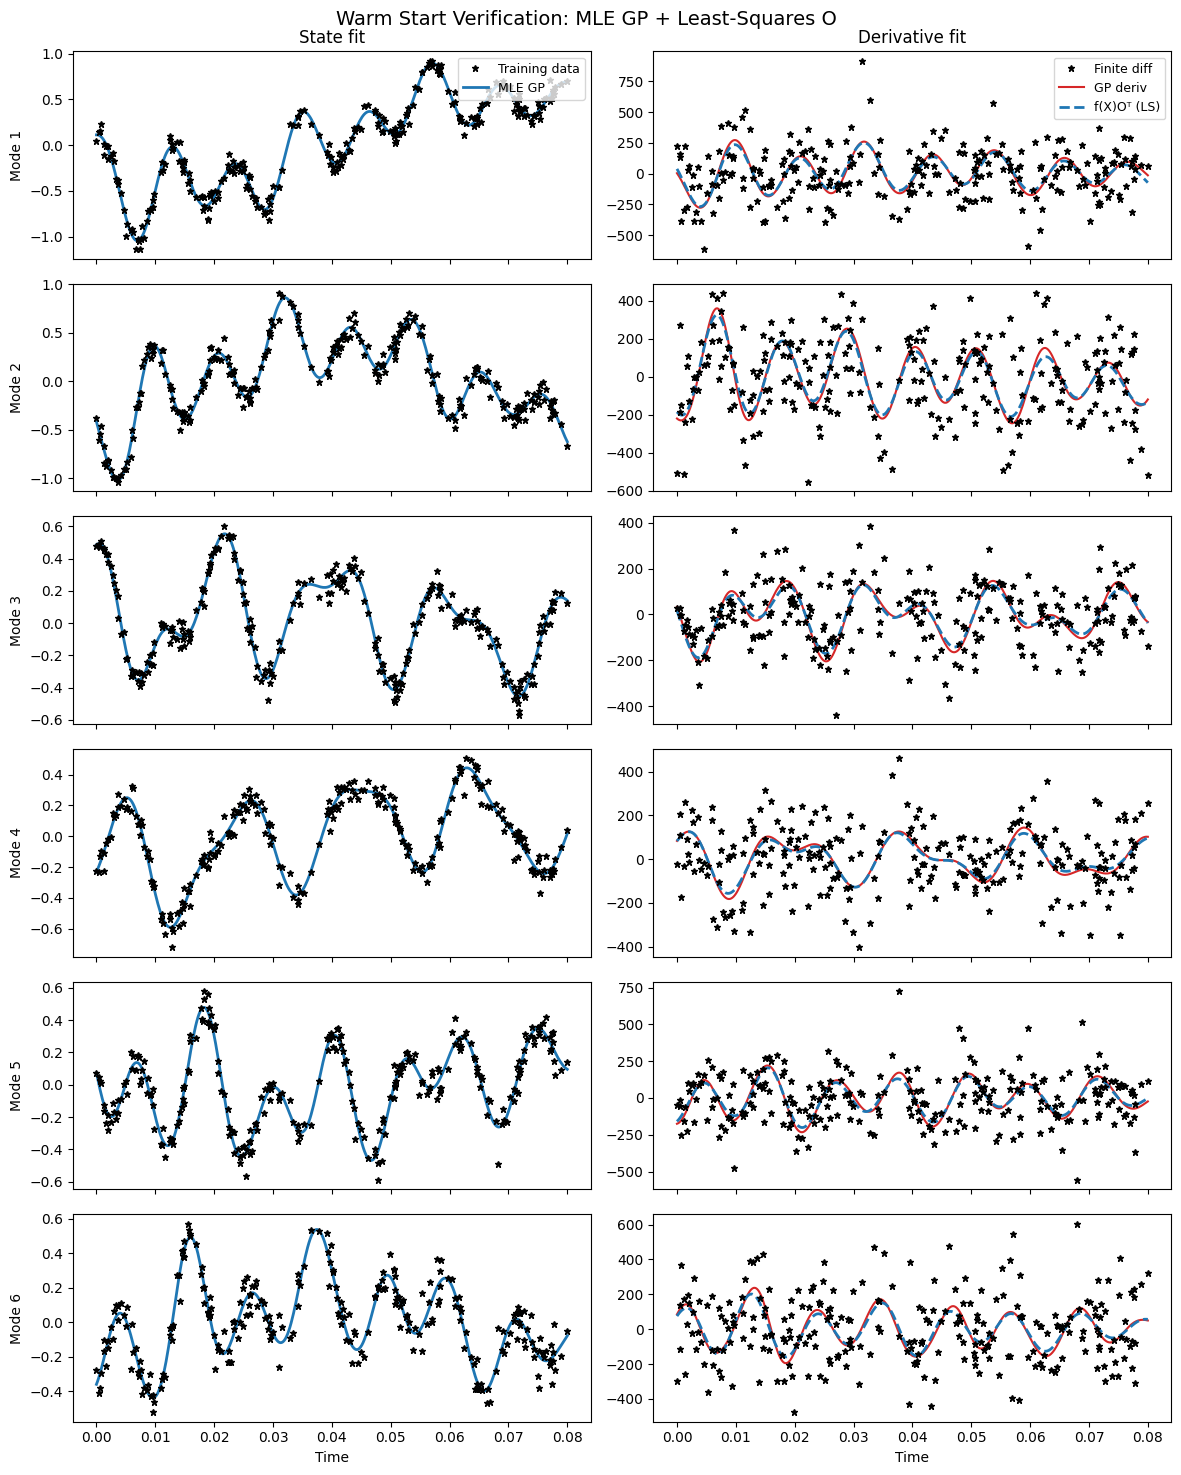

In [23]:
fig, axes = plt.subplots(NUM_MODES, 2, figsize=(12, 2.5 * NUM_MODES), sharex=True)
if NUM_MODES == 1:
    axes = axes[np.newaxis, :]

fd_derivs = compute_derivatives_fourth_order(training_data, time_sampled)

for i in range(NUM_MODES):
    # Left: state fit
    ax = axes[i, 0]
    ax.plot(time_sampled, training_data[i], 'k*', ms=5, label='Training data', zorder=5)
    ax.plot(time_eval_ls, X_mle[i], color='tab:blue', lw=2, label='MLE GP')
    ax.set_ylabel(f'Mode {i+1}')
    if i == 0:
        ax.set_title(f'State fit')
        ax.legend(loc='upper right', fontsize=9)

    # Right: derivative fit
    ax2 = axes[i, 1]
    ax2.plot(time_sampled, fd_derivs[i], 'k*', ms=5, label='Finite diff', zorder=5)
    ax2.plot(time_eval_ls, np.array(mu_z_mle[i]), color='tab:red', lw=1.5, label='GP deriv')
    # Overlay f(X) @ O^T
    f_Xi_check = D @ O_lstsq  # (n_eval, num_modes)
    if USE_SCALED_DATA and data_scaler is not None:
        f_Xi_scaled_check = f_Xi_check[:, i] / data_scaler.stds_[i, 0]
    else:
        f_Xi_scaled_check = f_Xi_check[:, i]
    ax2.plot(time_eval_ls, f_Xi_scaled_check, color='tab:blue', linestyle='--', lw=2, label='f(X)O\u1d40 (LS)')
    if i == 0:
        ax2.set_title(f'Derivative fit')
        ax2.legend(loc='upper right', fontsize=9)

axes[-1, 0].set_xlabel('Time')
axes[-1, 1].set_xlabel('Time')
fig.suptitle('Warm Start Verification: MLE GP + Least-Squares O', fontsize=14)
fig.tight_layout()
plt.show()

## 5. Joint SVI with Warm Start

Build the same marginal-likelihood joint model as notebook 03, but initialise
the AutoNormal guide from the MLE/LS values.

In [24]:
# No β annealing needed — warm start puts us in the correct basin from step 1.

In [25]:
def build_annealed_joint_model(
    rom,
    num_modes,
    time_domain_sampled,
    snapshots,
    inputs_eval=None,
    data_scaler=None,
    gp_lengthscale_prior_loc=None,
    gp_lengthscale_prior_scale=1.0,
    gp_variance_prior_loc=None,
    gp_variance_prior_scale=0.5,
    gp_noise_prior_loc=None,
    gp_noise_prior_scale=1.0,
    gamma2_prior_loc=None,
    gamma2_prior_scale=1.0,
    learn_gamma2=True,
    num_eval_points=None,
):
    """
    Build a joint Bayesian model with KL annealing support.

    Uses the GP marginal likelihood approach: X is analytically
    marginalised via  y ~ N(0, K + νI),  then recovered deterministically
    as the GP conditional mean  X = K @ (K + νI)^{-1} y.

    Returns (model, time_eval) where model has signature:
        model(gamma, gamma2, jitter, beta)
    """
    t_train = jnp.array(time_domain_sampled)
    n_train = len(t_train)
    T = float(t_train[-1] - t_train[0])
    y_obs = jnp.array(snapshots)
    use_scaled = data_scaler is not None

    if num_eval_points is not None:
        time_eval = jnp.linspace(float(t_train[0]), float(t_train[-1]), num_eval_points)
    else:
        time_eval = t_train
    n_eval = len(time_eval)

    inputs_eval_jnp = jnp.array(inputs_eval) if inputs_eval is not None else None

    # Default GP priors
    if gp_lengthscale_prior_loc is None:
        gp_lengthscale_prior_loc = jnp.full(num_modes, jnp.log(T / 20.0))
    else:
        gp_lengthscale_prior_loc = jnp.broadcast_to(
            jnp.asarray(gp_lengthscale_prior_loc, dtype=float), (num_modes,))
    if gp_variance_prior_loc is None:
        gp_variance_prior_loc = jnp.array([
            jnp.log(jnp.var(y_obs[i]) + 1e-8) for i in range(num_modes)])
    else:
        gp_variance_prior_loc = jnp.broadcast_to(
            jnp.asarray(gp_variance_prior_loc, dtype=float), (num_modes,))
    if gp_noise_prior_loc is None:
        gp_noise_prior_loc = jnp.full(num_modes, -8.0)
    else:
        gp_noise_prior_loc = jnp.broadcast_to(
            jnp.asarray(gp_noise_prior_loc, dtype=float), (num_modes,))

    _learn_gamma2 = learn_gamma2
    _gamma2_prior_scale = gamma2_prior_scale
    _gamma2_prior_loc = gamma2_prior_loc
    op_shape = rom.model.operator_matrix.shape

    # Precompute distance matrices
    sq_diff_tt = (t_train[:, None] - t_train[None, :]) ** 2
    I_train = jnp.eye(n_train)
    I_eval = jnp.eye(n_eval)

    if num_eval_points is not None:
        diffs_et = time_eval[:, None] - t_train[None, :]
        sq_diffs_et = diffs_et ** 2
        sq_diffs_ee = (time_eval[:, None] - time_eval[None, :]) ** 2
    else:
        diffs_et = t_train[:, None] - t_train[None, :]
        sq_diffs_et = sq_diff_tt
        sq_diffs_ee = sq_diff_tt

    if use_scaled:
        scale_stds = jnp.array([data_scaler.stds_[i, 0] for i in range(num_modes)])
        scale_means = jnp.array([data_scaler.means_[i, 0] for i in range(num_modes)])

    def _rbf_sq(ell, sig2, sq_diffs):
        return sig2 * jnp.exp(-sq_diffs / (2.0 * ell ** 2))

    def _single_marginal_gp(ell, sig2, nu, y_i, base_jitter):
        K = _rbf_sq(ell, sig2, sq_diff_tt)
        K_y = K + (nu + base_jitter) * I_train
        L_y = jnp.linalg.cholesky(K_y)
        K_inv_y = jax.scipy.linalg.cho_solve((L_y, True), y_i)
        X_i = K @ K_inv_y
        return L_y, K_inv_y, X_i, K

    def _single_interp_and_deriv(ell, sig2, L_y, K_inv_y):
        ell2 = ell ** 2
        K_et = _rbf_sq(ell, sig2, sq_diffs_et)
        X_eval_i = K_et @ K_inv_y
        K_zy = -(diffs_et / ell2) * K_et
        mu_z_i = K_zy @ K_inv_y
        K_ee = _rbf_sq(ell, sig2, sq_diffs_ee)
        K_zz = ((1.0 - sq_diffs_ee / ell2) / ell2) * K_ee
        V = jax.scipy.linalg.solve_triangular(L_y, K_zy.T, lower=True)
        A_i = K_zz - V.T @ V
        A_i = 0.5 * (A_i + A_i.T)
        return X_eval_i, mu_z_i, A_i

    _batch_marginal_gp = jax.vmap(_single_marginal_gp, in_axes=(0, 0, 0, 0, None))
    _batch_interp_deriv = jax.vmap(_single_interp_and_deriv)

    def model(gamma=1.0, gamma2=1.0, jitter=1e-4, beta=1.0):

        def _scaled_sample(name, prior_dist):
            x = numpyro.sample(name, prior_dist.mask(False))
            numpyro.factor(f"{name}_kl_scale", beta * prior_dist.log_prob(x))
            return x

        # γ₂ per mode (β-scaled)
        if _learn_gamma2:
            g2_loc = _gamma2_prior_loc if _gamma2_prior_loc is not None else jnp.log(gamma2)
            gamma2_arr = jnp.stack([
                _scaled_sample(f"gamma2_{i}", dist.LogNormal(g2_loc, _gamma2_prior_scale))
                for i in range(num_modes)])
        else:
            gamma2_arr = jnp.full(num_modes, gamma2)

        # GP hyperparameters (full strength)
        ells = jnp.stack([
            numpyro.sample(f"lengthscale_{i}",
                           dist.LogNormal(gp_lengthscale_prior_loc[i], gp_lengthscale_prior_scale))
            for i in range(num_modes)])
        sig2s = jnp.stack([
            numpyro.sample(f"variance_{i}",
                           dist.LogNormal(gp_variance_prior_loc[i], gp_variance_prior_scale))
            for i in range(num_modes)])
        nus = jnp.stack([
            numpyro.sample(f"noise_{i}",
                           dist.LogNormal(gp_noise_prior_loc[i], gp_noise_prior_scale))
            for i in range(num_modes)])

        # GP marginal likelihood
        L_ys, K_inv_ys, Xs, Ks = _batch_marginal_gp(ells, sig2s, nus, y_obs, jitter)

        for i in range(num_modes):
            K_y_i = Ks[i] + (nus[i] + jitter) * I_train
            numpyro.sample(f"obs_{i}",
                           dist.MultivariateNormal(jnp.zeros(n_train), K_y_i),
                           obs=y_obs[i])
            numpyro.deterministic(f"X_{i}", Xs[i])

        # Interpolation + derivative conditioning
        Xs_eval_interp, mu_zs, As = _batch_interp_deriv(ells, sig2s, L_ys, K_inv_ys)

        if num_eval_points is not None:
            Xs_eval = Xs_eval_interp
            for i in range(num_modes):
                numpyro.deterministic(f"X_eval_{i}", Xs_eval[i])
        else:
            Xs_eval = Xs

        # Operator O (β-scaled prior)
        O = _scaled_sample("O",
            dist.Normal(jnp.zeros(op_shape), gamma * jnp.ones(op_shape)))

        # Transform to original space if scaled
        if use_scaled:
            Xs_eval_original = Xs_eval * scale_stds[:, None] + scale_means[:, None]
        else:
            Xs_eval_original = Xs_eval

        # Compute operator dynamics
        f_Xi = rom.model._assemble_data_matrix(
            Xs_eval_original, inputs=inputs_eval_jnp) @ O.T

        if use_scaled:
            f_Xi_scaled = f_Xi.T / scale_stds[:, None]
        else:
            f_Xi_scaled = f_Xi.T

        # ODE constraints (β-scaled, diagonal approximation)
        # Uses marginal variances from the derivative posterior to avoid
        # Cholesky failures on the full Schur complement covariance.
        # TODO: Verify diagonal approx is sufficient — drops derivative
        # correlations across time points. Defensible when γ₂ >> diag(A),
        # and consistent with pointwise matching in Calderhead et al. (2009).
        for i in range(num_modes):
            numpyro.deterministic(f"mu_z_{i}", mu_zs[i])
            g2_eff = jnp.maximum(gamma2_arr[i], 1e-2) + jitter
            deriv_var = jnp.maximum(jnp.diag(As[i]), 0.0) + g2_eff
            ode_dist = dist.Normal(loc=f_Xi_scaled[i], scale=jnp.sqrt(deriv_var))
            numpyro.factor(f"ode_constraint_{i}",
                           beta * jnp.sum(ode_dist.log_prob(mu_zs[i])))

    return model, np.array(time_eval)


print("Model builder defined (GP marginal likelihood approach).")

Model builder defined (GP marginal likelihood approach).


In [26]:
def run_warm_start_svi(
    model,
    rng_key,
    init_values,
    gamma=1.0,
    gamma2=1.0,
    jitter=1e-4,
    num_steps=10000,
    learning_rate=1e-3,
    num_samples=1000,
    verbose=True,
    guide_class=None,
    num_log_segments=20,
):
    """
    Run SVI with warm-started guide parameters (β=1.0 throughout).

    Parameters
    ----------
    init_values : dict
        Initial values for guide parameters, keyed by sample site name.
        E.g. {'lengthscale_0': 0.005, 'O': O_init_array, ...}
    """
    if guide_class is None:
        guide_class = autoguide.AutoNormal

    guide = guide_class(model, init_loc_fn=init_to_value(values=init_values))
    optimizer = ClippedAdam(step_size=learning_rate)
    svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

    betas_jnp = jnp.ones(num_steps)

    if verbose:
        print(f"Running warm-started joint SVI:")
        print(f"  Total steps: {num_steps}, β=1.0 (no annealing)")
        print(f"  gamma={gamma}, gamma2={gamma2}, lr={learning_rate}")
        print(f"  Init values: {sorted(init_values.keys())}")
        print(f"  Compiling model (this may take a few minutes)...")

    # Initialise SVI state
    rng_key, init_key = random.split(rng_key)
    svi_state = svi.init(
        init_key, gamma=gamma, gamma2=gamma2, jitter=jitter, beta=betas_jnp[0])

    @jax.jit
    def _scan_body(svi_state, beta_val):
        svi_state, loss = svi.update(
            svi_state, gamma=gamma, gamma2=gamma2, jitter=jitter, beta=beta_val)
        return svi_state, loss

    def _run_segment(svi_state, betas_segment):
        svi_state, losses = jax.lax.scan(_scan_body, svi_state, betas_segment)
        return svi_state, losses

    # Split into segments for progress logging
    segment_size = max(1, num_steps // num_log_segments)
    all_losses = []
    cumulative = 0

    if verbose:
        print(f"  Compilation + first segment running...")

    for seg_idx in range(num_log_segments):
        start = seg_idx * segment_size
        end = min(start + segment_size, num_steps)
        if seg_idx == num_log_segments - 1:
            end = num_steps
        if start >= num_steps:
            break

        svi_state, seg_losses = _run_segment(svi_state, betas_jnp[start:end])
        seg_losses_np = np.array(seg_losses)
        all_losses.extend(seg_losses_np.tolist())
        cumulative += (end - start)

        if verbose:
            print(f"  step {cumulative:6d}/{num_steps}  "
                  f"loss={seg_losses_np[-1]:12.2f}")

    # Extract final parameters and draw posterior samples
    params = svi.get_params(svi_state)
    model_kwargs = dict(gamma=gamma, gamma2=gamma2, jitter=jitter, beta=1.0)
    rng_key, sample_key, pred_key = random.split(rng_key, 3)

    posterior_samples = guide.sample_posterior(
        sample_key, params, sample_shape=(num_samples,), **model_kwargs)
    predictive = Predictive(
        model, posterior_samples=posterior_samples, num_samples=num_samples,
        return_sites=None)
    model_output = predictive(pred_key, **model_kwargs)
    samples = {**model_output, **posterior_samples}

    if verbose:
        print(f"\n✅ Warm-started SVI complete! Final loss: {all_losses[-1]:.4f}")
        print(f"   Sample keys: {sorted(samples.keys())}")

    result = SVIResult(samples=samples, params=params, losses=all_losses)
    return result


print("Warm-start SVI runner defined.")


Warm-start SVI runner defined.


### Build Model and Prepare Warm Start

In [27]:
start_time = time.time()

# Centre GP priors on MLE values (log-space)
GP_LENGTHSCALE_PRIOR_LOC = np.log(mle_Ls)
GP_VARIANCE_PRIOR_LOC = np.log(mle_Vs)
GP_NOISE_PRIOR_LOC = np.log(mle_Ns)

# Build the joint model
joint_model, time_eval = build_annealed_joint_model(
    rom=rom,
    num_modes=NUM_MODES,
    time_domain_sampled=time_sampled,
    snapshots=training_data,
    inputs_eval=None,
    data_scaler=data_scaler if USE_SCALED_DATA else None,
    gp_lengthscale_prior_loc=GP_LENGTHSCALE_PRIOR_LOC,
    gp_lengthscale_prior_scale=GP_LENGTHSCALE_PRIOR_SCALE,
    gp_variance_prior_loc=GP_VARIANCE_PRIOR_LOC,
    gp_variance_prior_scale=GP_VARIANCE_PRIOR_SCALE,
    gp_noise_prior_loc=GP_NOISE_PRIOR_LOC,
    gp_noise_prior_scale=GP_NOISE_PRIOR_SCALE,
    gamma2_prior_loc=GAMMA2_PRIOR_LOC,
    gamma2_prior_scale=GAMMA2_PRIOR_SCALE,
    learn_gamma2=LEARN_GAMMA2,
    num_eval_points=NUM_EVAL_POINTS,
)

# Build init_values dict: MLE GP hyperparams + LS operator
init_values = {}
for i in range(NUM_MODES):
    init_values[f'lengthscale_{i}'] = mle_Ls[i]
    init_values[f'variance_{i}'] = mle_Vs[i]
    init_values[f'noise_{i}'] = mle_Ns[i]
init_values['O'] = jnp.array(O_init)

print(f"Joint model built. Eval points: {len(time_eval)}")
print(f"Init values prepared: {sorted(init_values.keys())}")

Joint model built. Eval points: 400
Init values prepared: ['O', 'lengthscale_0', 'lengthscale_1', 'lengthscale_2', 'lengthscale_3', 'lengthscale_4', 'lengthscale_5', 'noise_0', 'noise_1', 'noise_2', 'noise_3', 'noise_4', 'noise_5', 'variance_0', 'variance_1', 'variance_2', 'variance_3', 'variance_4', 'variance_5']


In [28]:
svi_result = run_warm_start_svi(
    model=joint_model,
    rng_key=rng_key,
    init_values=init_values,
    gamma=GAMMA,
    gamma2=GAMMA2,
    jitter=1e-5,
    num_steps=NUM_SVI_STEPS,
    learning_rate=LEARNING_RATE,
    num_samples=NUM_POSTERIOR_SAMPLES,
    verbose=VERBOSE,
    guide_class=GUIDE,
)

algo_time = time.time() - start_time
print(f"\nAlgorithm runtime: {algo_time:.1f}s ({algo_time/60:.1f}min)")


Running warm-started joint SVI:
  Total steps: 10000, β=1.0 (no annealing)
  gamma=0.5, gamma2=10.0, lr=0.001
  Init values: ['O', 'lengthscale_0', 'lengthscale_1', 'lengthscale_2', 'lengthscale_3', 'lengthscale_4', 'lengthscale_5', 'noise_0', 'noise_1', 'noise_2', 'noise_3', 'noise_4', 'noise_5', 'variance_0', 'variance_1', 'variance_2', 'variance_3', 'variance_4', 'variance_5']
  Compiling model (this may take a few minutes)...
  Compilation + first segment running...
  step    500/10000  loss=  1479860.00
  step   1000/10000  loss=  1469914.25
  step   1500/10000  loss=  1458986.88
  step   2000/10000  loss=  1449220.00
  step   2500/10000  loss=  1439854.88
  step   3000/10000  loss=  1429837.00
  step   3500/10000  loss=  1420854.50
  step   4000/10000  loss=  1411195.00
  step   4500/10000  loss=  1402397.62
  step   5000/10000  loss=  1393742.88
  step   5500/10000  loss=  1384930.88
  step   6000/10000  loss=  1377166.38
  step   6500/10000  loss=  1368059.75
  step   7000/1000

### Convergence Diagnostics

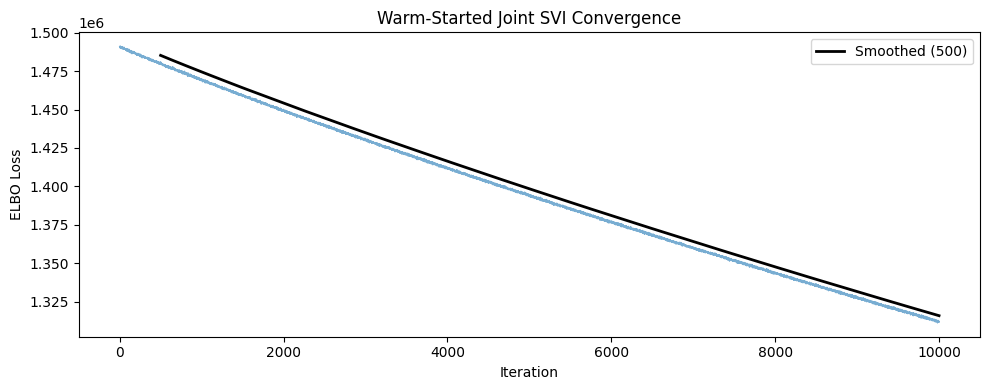

In [29]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))

ax.plot(svi_result.losses, lw=1, alpha=0.6)
window = min(500, len(svi_result.losses) // 10)
if window > 1:
    smoothed = np.convolve(svi_result.losses, np.ones(window)/window, mode='valid')
    ax.plot(np.arange(window-1, window-1+len(smoothed)), smoothed, 'k-', lw=2, label=f'Smoothed ({window})')
ax.set_xlabel('Iteration')
ax.set_ylabel('ELBO Loss')
ax.set_title('Warm-Started Joint SVI Convergence')
ax.legend()

plt.tight_layout()
plt.show()


In [30]:
samples = svi_result.samples

print("Inferred GP Hyperparameters (median) vs MLE:")
print(f"  {'Mode':>4s}  {'ℓ_SVI':>8s}  {'ℓ_MLE':>8s}  {'σ²_SVI':>8s}  {'σ²_MLE':>8s}  {'ν_SVI':>10s}  {'ν_MLE':>10s}")
for i in range(NUM_MODES):
    L_i = np.median(samples[f'lengthscale_{i}'])
    V_i = np.median(samples[f'variance_{i}'])
    N_i = np.median(samples[f'noise_{i}'])
    print(f"  {i:4d}  {L_i:8.5f}  {mle_Ls[i]:8.5f}  {V_i:8.4f}  {mle_Vs[i]:8.4f}  {N_i:10.6f}  {mle_Ns[i]:10.6f}")

if LEARN_GAMMA2:
    print("\nInferred ODE constraint slack γ₂ (median):")
    for i in range(NUM_MODES):
        g2_i = np.median(samples[f'gamma2_{i}'])
        print(f"  Mode {i}: γ₂={g2_i:.4f}")

Inferred GP Hyperparameters (median) vs MLE:
  Mode     ℓ_SVI     ℓ_MLE    σ²_SVI    σ²_MLE       ν_SVI       ν_MLE
     0   0.00413   0.00423    0.0196    0.3300    0.019260    0.005277
     1   0.00476   0.00392    0.0687    0.2913    0.020635    0.005780
     2   0.00389   0.00399    0.0203    0.1096    0.014725    0.002668
     3   0.00390   0.00456    0.0169    0.1086    0.012207    0.003239
     4   0.00215   0.00364    0.0542    0.1213    0.011143    0.004204
     5   0.00486   0.00337    0.0556    0.0882    0.012327    0.006151

Inferred ODE constraint slack γ₂ (median):
  Mode 0: γ₂=9.8816
  Mode 1: γ₂=10.1087
  Mode 2: γ₂=10.4405
  Mode 3: γ₂=10.5708
  Mode 4: γ₂=10.3804
  Mode 5: γ₂=10.1233


## 6. Diagnostic Plots

### Plot 1: GP Fit

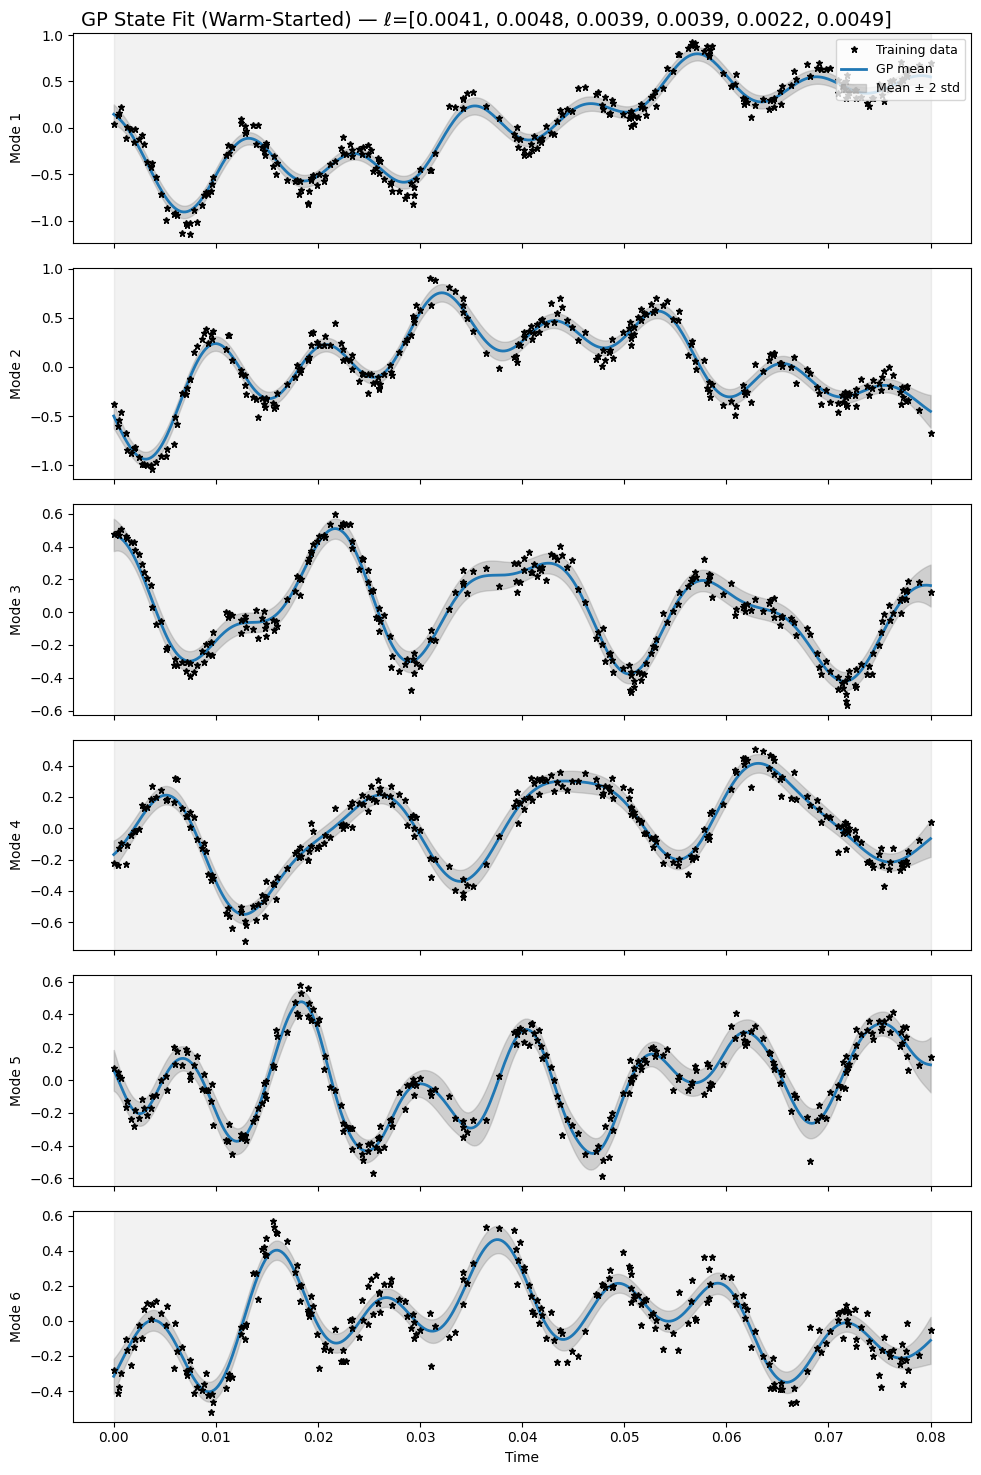

In [31]:
gp_means, gp_stds, Ls, Vs, Ns = extract_gp_posterior(
    samples, NUM_MODES, time_sampled, time_domain_eval_training, training_data,
)

fig, axes = plt.subplots(NUM_MODES, 1, figsize=(10, 2.5 * NUM_MODES), sharex=True)
if NUM_MODES == 1:
    axes = [axes]

for i in range(NUM_MODES):
    ax = axes[i]
    ax.axvspan(TRAINING_SPAN[0], TRAINING_SPAN[1], color='gray', alpha=0.10, zorder=0)
    ax.plot(time_sampled, training_data[i], 'k*', ms=5, label='Training data', zorder=5)
    ax.plot(time_domain_eval_training, gp_means[i], color='tab:blue', lw=2, label='GP mean')
    ax.fill_between(
        time_domain_eval_training,
        gp_means[i] - 2 * gp_stds[i],
        gp_means[i] + 2 * gp_stds[i],
        color='gray', alpha=0.3, label='Mean ± 2 std',
    )
    ax.set_ylabel(f'Mode {i+1}')
    if i == 0:
        ax.legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel('Time')
fig.suptitle(f'GP State Fit (Warm-Started) — ℓ=[{", ".join(f"{l:.4f}" for l in Ls)}]', fontsize=14)
fig.tight_layout()
plt.show()

### Plot 2: Derivative GP Fit

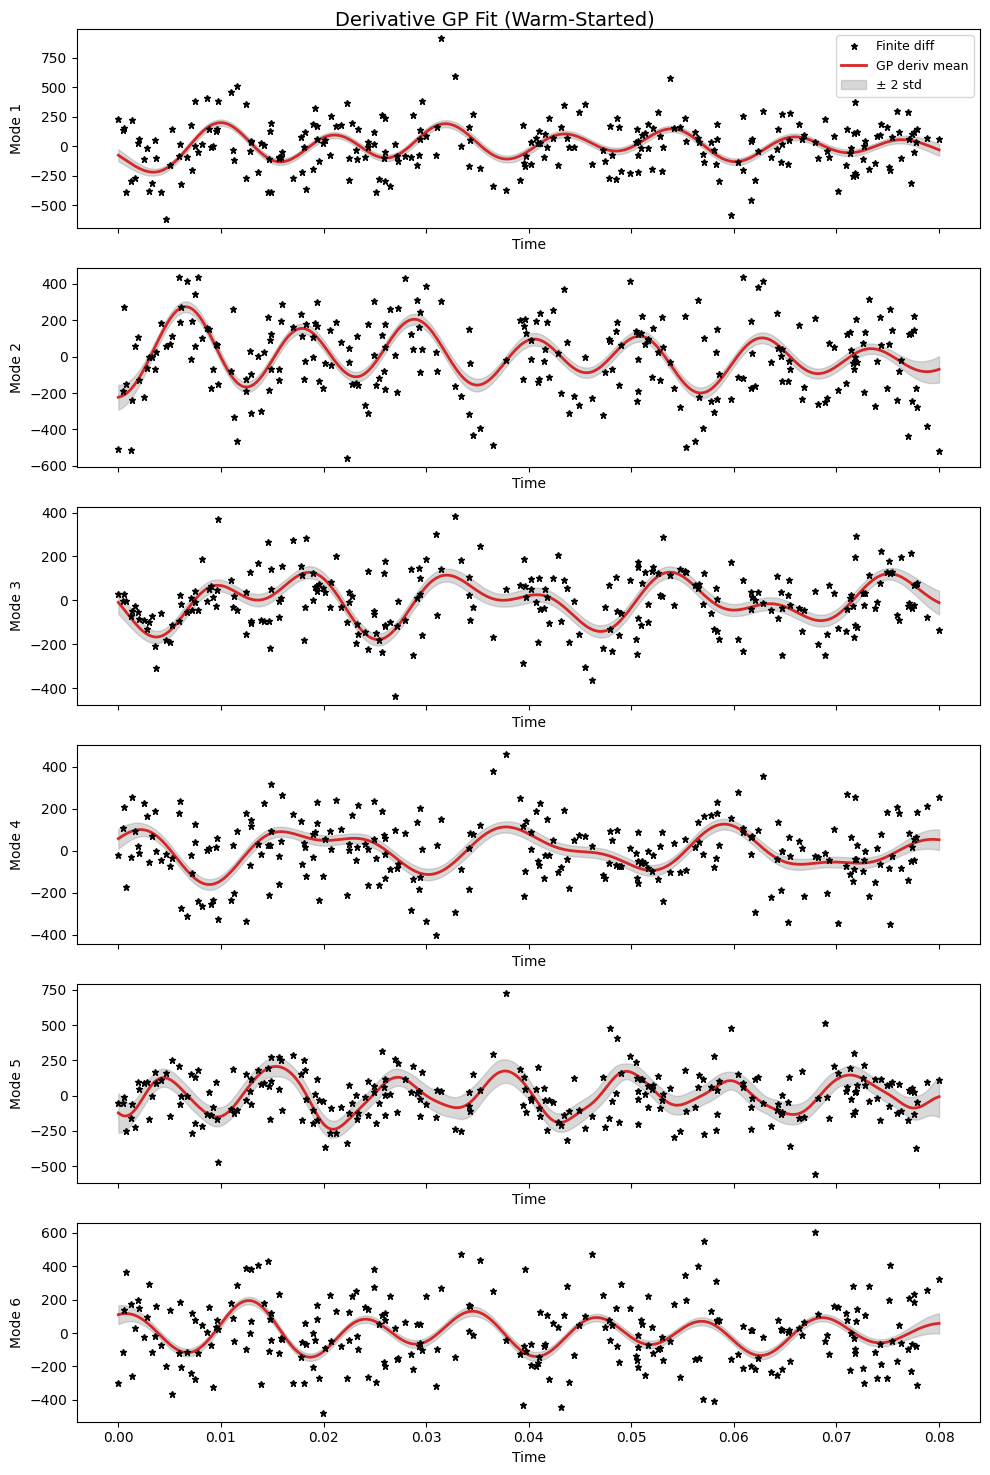

In [32]:
mu_z, std_z = extract_derivative_posterior(
    Ls, Vs, Ns, time_sampled, time_domain_eval_training, training_data,
)

fd_derivs = compute_derivatives_fourth_order(training_data, time_sampled)

fig, axes = plt.subplots(NUM_MODES, 1, figsize=(10, 2.5 * NUM_MODES), sharex=True)
if NUM_MODES == 1:
    axes = [axes]

for i in range(NUM_MODES):
    ax = axes[i]
    ax.plot(time_sampled, fd_derivs[i], 'k*', ms=5, label='Finite diff', zorder=5)
    ax.plot(time_domain_eval_training, mu_z[i], color='tab:red', lw=2, label='GP deriv mean')
    ax.fill_between(
        time_domain_eval_training,
        mu_z[i] - 2 * std_z[i],
        mu_z[i] + 2 * std_z[i],
        color='gray', alpha=0.3, label='± 2 std',
    )
    ax.set_ylabel(f'Mode {i+1}')
    if i == 0:
        ax.legend(loc='upper right', fontsize=9)
    ax.set_xlabel('Time')

fig.suptitle('Derivative GP Fit (Warm-Started)', fontsize=14)
fig.tight_layout()
plt.show()

### Plot 3: GP-based OpInf Integration (Baseline)

Grid search: testing 41 regularization values...
  reg=1.0e-16: UNSTABLE
  reg=3.2e-16: UNSTABLE
  reg=1.0e-15: UNSTABLE
  reg=3.2e-15: UNSTABLE
  reg=1.0e-14: UNSTABLE
  reg=3.2e-14: UNSTABLE
  reg=1.0e-13: UNSTABLE
  reg=3.2e-13: UNSTABLE
  reg=1.0e-12: UNSTABLE
  reg=3.2e-12: UNSTABLE
  reg=1.0e-11: UNSTABLE
  reg=3.2e-11: UNSTABLE
  reg=1.0e-10: UNSTABLE
  reg=3.2e-10: UNSTABLE
  reg=1.0e-09: UNSTABLE
  reg=3.2e-09: UNSTABLE
  reg=1.0e-08: UNSTABLE
  reg=3.2e-08: UNSTABLE
  reg=1.0e-07: UNSTABLE
  reg=3.2e-07: UNSTABLE
  reg=1.0e-06: UNSTABLE
  reg=3.2e-06: UNSTABLE
  reg=1.0e-05: UNSTABLE
  reg=3.2e-05: UNSTABLE
  reg=1.0e-04: UNSTABLE
  reg=3.2e-04: UNSTABLE
  reg=1.0e-03: UNSTABLE
  reg=3.2e-03: UNSTABLE
  reg=1.0e-02: UNSTABLE
  reg=3.2e-02: UNSTABLE
  reg=1.0e-01: UNSTABLE
  reg=3.2e-01: STABLE, error=0.270878
  reg=1.0e+00: STABLE, error=0.722060
  reg=3.2e+00: STABLE, error=1.146202
  reg=1.0e+01: STABLE, error=1.283210
  reg=3.2e+01: STABLE, error=1.433520
  reg=1.0e+02: ST

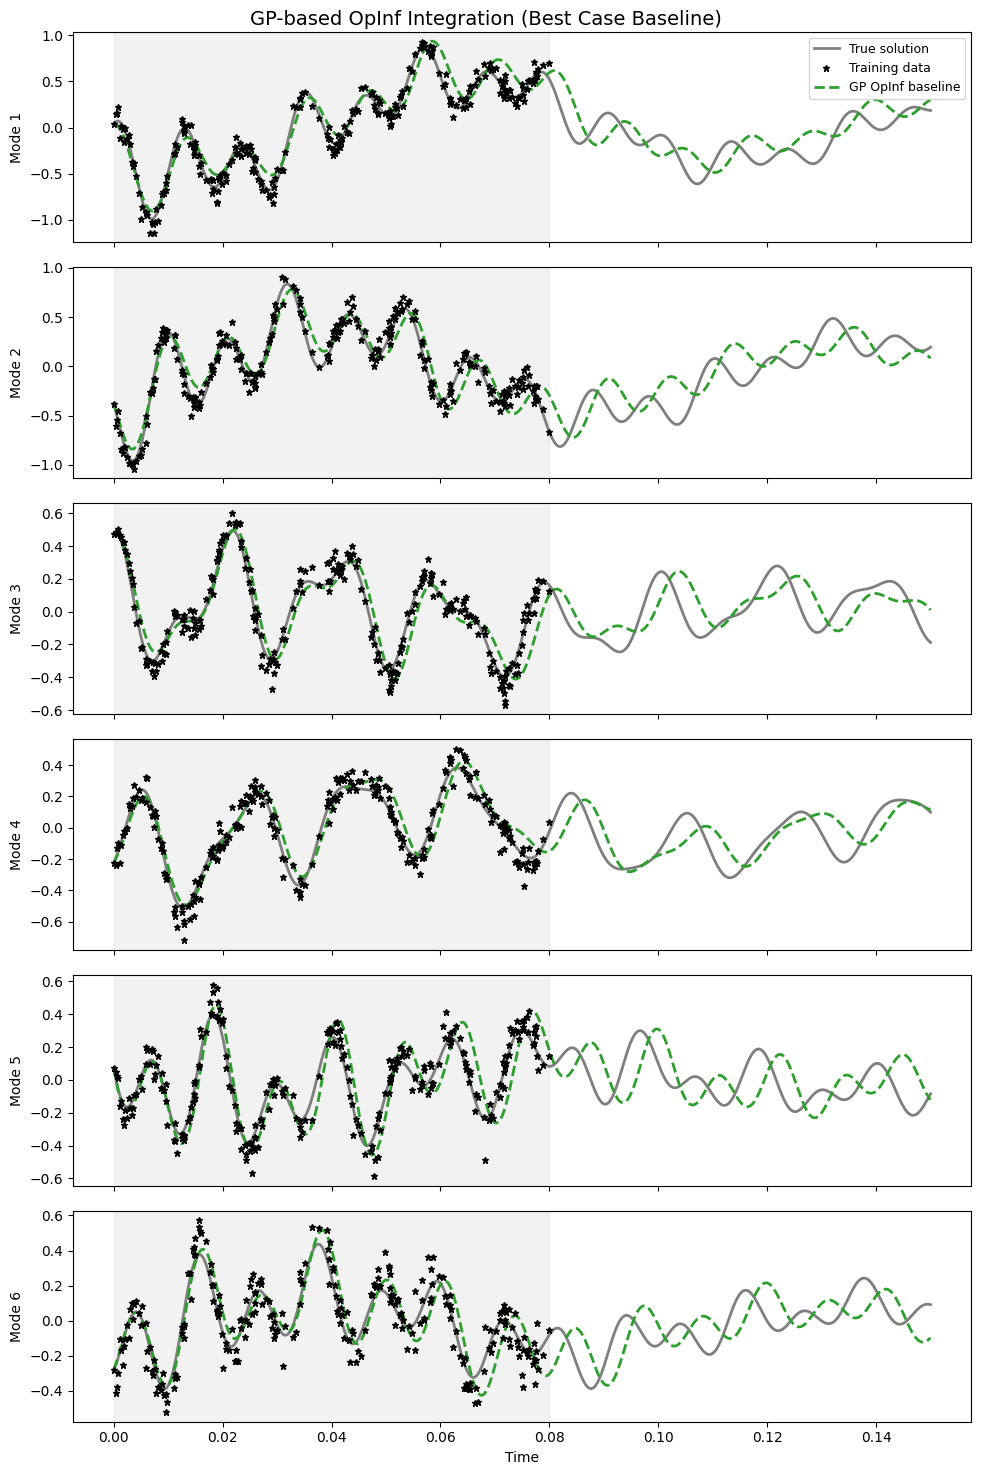

In [33]:
gp_means_train, _, _, _, _ = extract_gp_posterior(
    samples, NUM_MODES, time_sampled, time_sampled, training_data,
)

gp_baseline_result = gp_based_opinf_baseline(
    basis=basis,
    gp_means=gp_means_train,
    time_eval=time_sampled,
    snapshots_compressed=snapshots_comp_sampled,
    operators=OPERATORS,
    inputs=None,
    input_func=None,
    ivp_method=IVP_METHOD,
)
print(f"GP baseline reg: {gp_baseline_result.best_reg:.2e}, error: {gp_baseline_result.best_error:.4%}")

gp_baseline_rom = gp_baseline_result.rom
gp_baseline_rom.model._extract_operators(np.array(gp_baseline_result.operator))
try:
    gp_pred = gp_baseline_rom.model.predict(
        state0=snapshots_comp_sampled[:, 0],
        t=time_domain_eval_prediction,
    )
    gp_pred_sol = gp_baseline_rom.model.predict_result_
    gp_baseline_stable = gp_pred_sol.y.shape[1] >= len(time_domain_eval_prediction)
except Exception:
    gp_baseline_stable = False

fig, axes = plt.subplots(NUM_MODES, 1, figsize=(10, 2.5 * NUM_MODES), sharex=True)
if NUM_MODES == 1:
    axes = [axes]

for i in range(NUM_MODES):
    ax = axes[i]
    ax.axvspan(TRAINING_SPAN[0], TRAINING_SPAN[1], color='gray', alpha=0.10, zorder=0)
    ax.plot(time_domain_full, full_states_compressed[i], color='tab:gray', lw=2, label='True solution')
    ax.plot(time_sampled, snapshots_comp_sampled[i], 'k*', ms=5, label='Training data', zorder=5)
    if gp_baseline_stable:
        ax.plot(time_domain_eval_prediction, gp_pred_sol.y[i],
                color='tab:green', linestyle='--', lw=2, label='GP OpInf baseline')
    ax.set_ylabel(f'Mode {i+1}')
    if i == 0:
        ax.legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel('Time')
fig.suptitle('GP-based OpInf Integration (Best Case Baseline)', fontsize=14)
fig.tight_layout()
plt.show()

### Plot 4: Latent State Fit

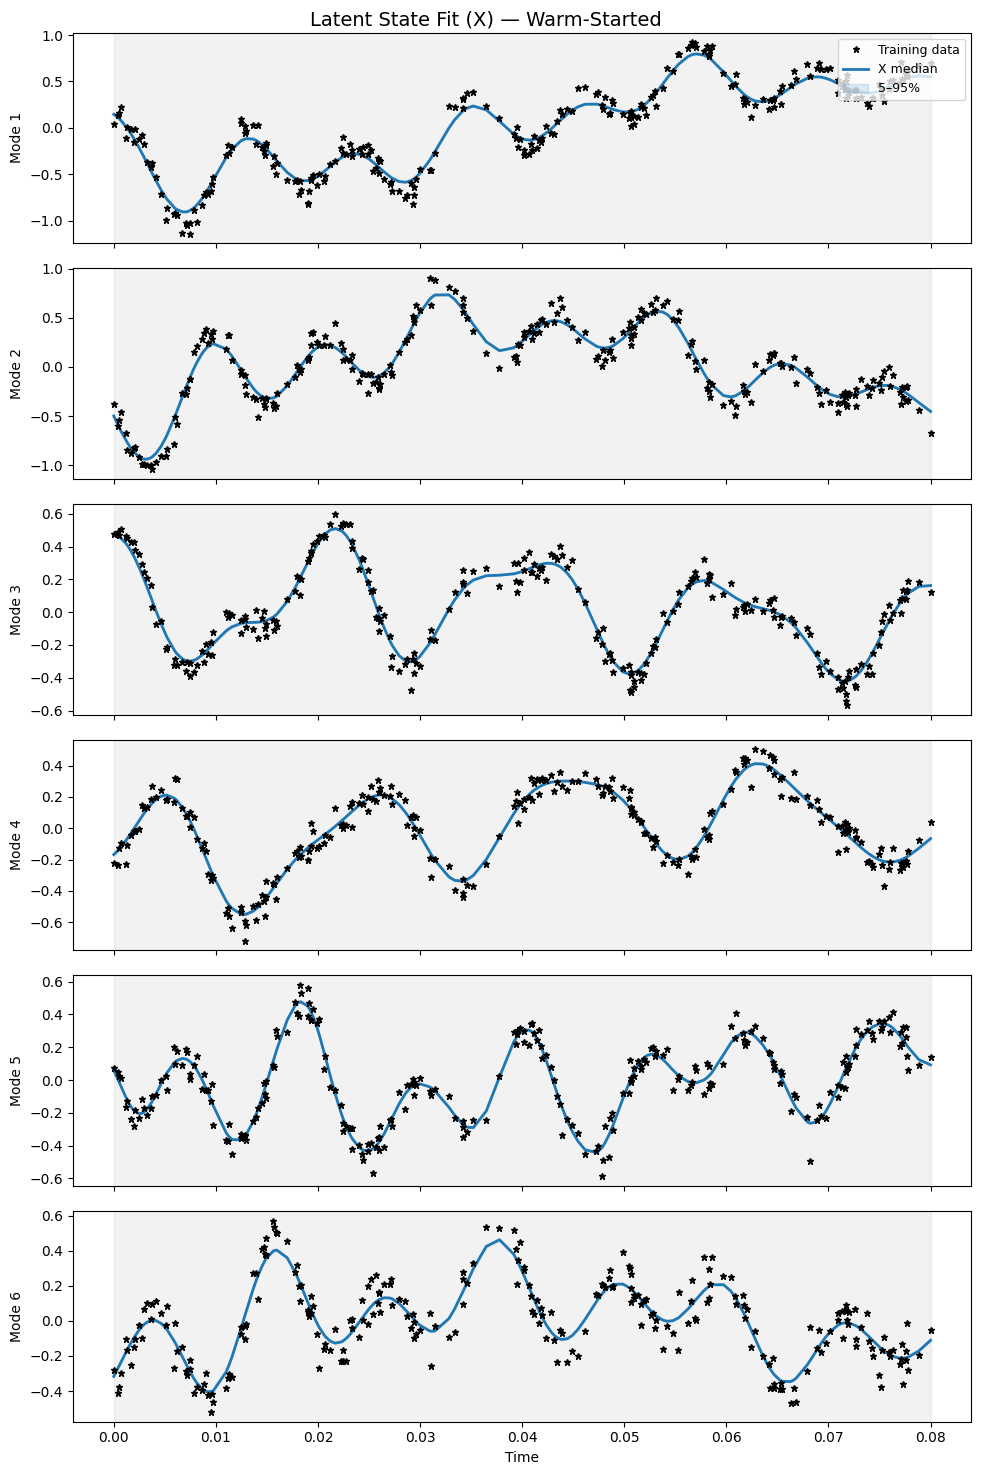

In [34]:
fig, axes = plt.subplots(NUM_MODES, 1, figsize=(10, 2.5 * NUM_MODES), sharex=True)
if NUM_MODES == 1:
    axes = [axes]

for i in range(NUM_MODES):
    ax = axes[i]
    X_i = np.array(samples[f'X_{i}'])
    X_median = np.median(X_i, axis=0)
    X_q05 = np.percentile(X_i, 5, axis=0)
    X_q95 = np.percentile(X_i, 95, axis=0)

    ax.axvspan(TRAINING_SPAN[0], TRAINING_SPAN[1], color='gray', alpha=0.10, zorder=0)
    ax.plot(time_sampled, training_data[i], 'k*', ms=5, label='Training data', zorder=5)
    ax.plot(time_sampled, X_median, color='tab:blue', lw=2, label='X median')
    ax.fill_between(time_sampled, X_q05, X_q95, color='tab:blue', alpha=0.15, label='5–95%')
    ax.set_ylabel(f'Mode {i+1}')
    if i == 0:
        ax.legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel('Time')
fig.suptitle('Latent State Fit (X) — Warm-Started', fontsize=14)
fig.tight_layout()
plt.show()

### Plot 5: Derivative Operator Fit

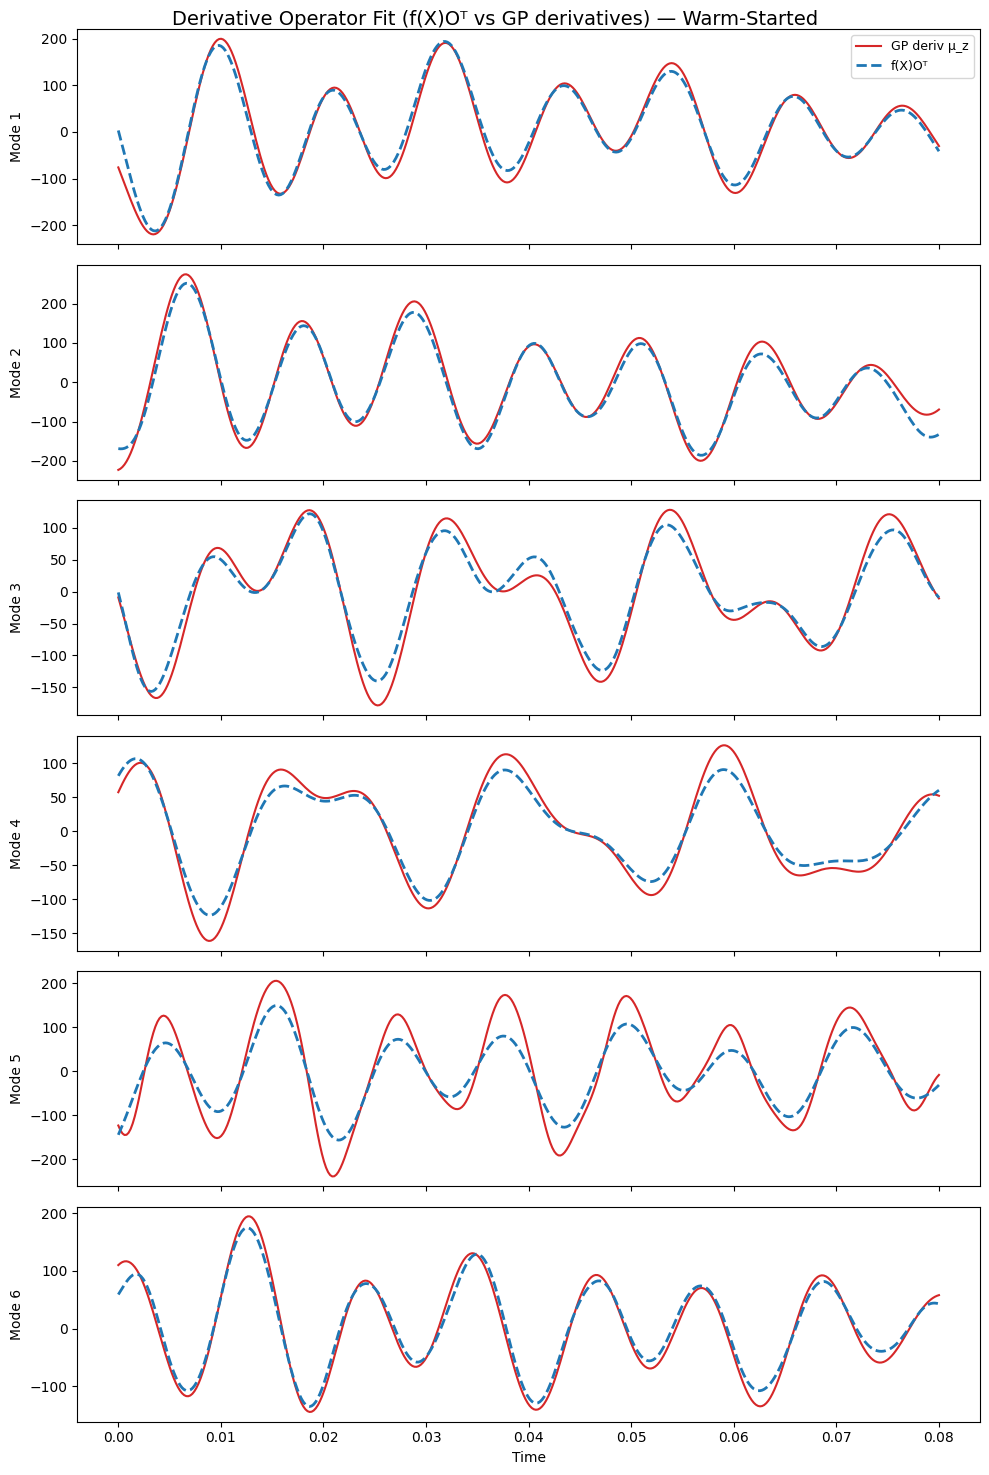

In [35]:
O_samples = _find_operator_samples(samples, "O")
if O_samples.ndim == 2:
    O_samples = O_samples[np.newaxis, ...]

O_median = np.median(O_samples, axis=0)

if f'X_eval_0' in samples:
    Xs_eval_median = np.array([np.median(samples[f'X_eval_{i}'], axis=0) for i in range(NUM_MODES)])
else:
    Xs_eval_median = np.array([np.median(samples[f'X_{i}'], axis=0) for i in range(NUM_MODES)])

if USE_SCALED_DATA and data_scaler is not None:
    Xs_eval_orig = np.array([
        Xs_eval_median[i] * data_scaler.stds_[i, 0] + data_scaler.means_[i, 0]
        for i in range(NUM_MODES)])
else:
    Xs_eval_orig = Xs_eval_median

f_X = np.array(rom.model._assemble_data_matrix(jnp.array(Xs_eval_orig), inputs=None) @ jnp.array(O_median).T)
if USE_SCALED_DATA and data_scaler is not None:
    f_X_scaled = np.array([f_X.T[i] / data_scaler.stds_[i, 0] for i in range(NUM_MODES)])
else:
    f_X_scaled = f_X.T

t_eval_plot = time_eval if f'X_eval_0' in samples else time_sampled

fig, axes = plt.subplots(NUM_MODES, 1, figsize=(10, 2.5 * NUM_MODES), sharex=True)
if NUM_MODES == 1:
    axes = [axes]

for i in range(NUM_MODES):
    ax = axes[i]
    ax.plot(time_domain_eval_training, mu_z[i], color='tab:red', lw=1.5, label='GP deriv μ_z')
    ax.plot(t_eval_plot, f_X_scaled[i], color='tab:blue', linestyle='--', lw=2, label='f(X)O\u1d40')
    ax.set_ylabel(f'Mode {i+1}')
    if i == 0:
        ax.legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel('Time')
fig.suptitle('Derivative Operator Fit (f(X)O\u1d40 vs GP derivatives) — Warm-Started', fontsize=14)
fig.tight_layout()
plt.show()

### Plot 6: Integrated Operator Fit (ROM Predictions)

Operator samples: 200, Stable solves: 200


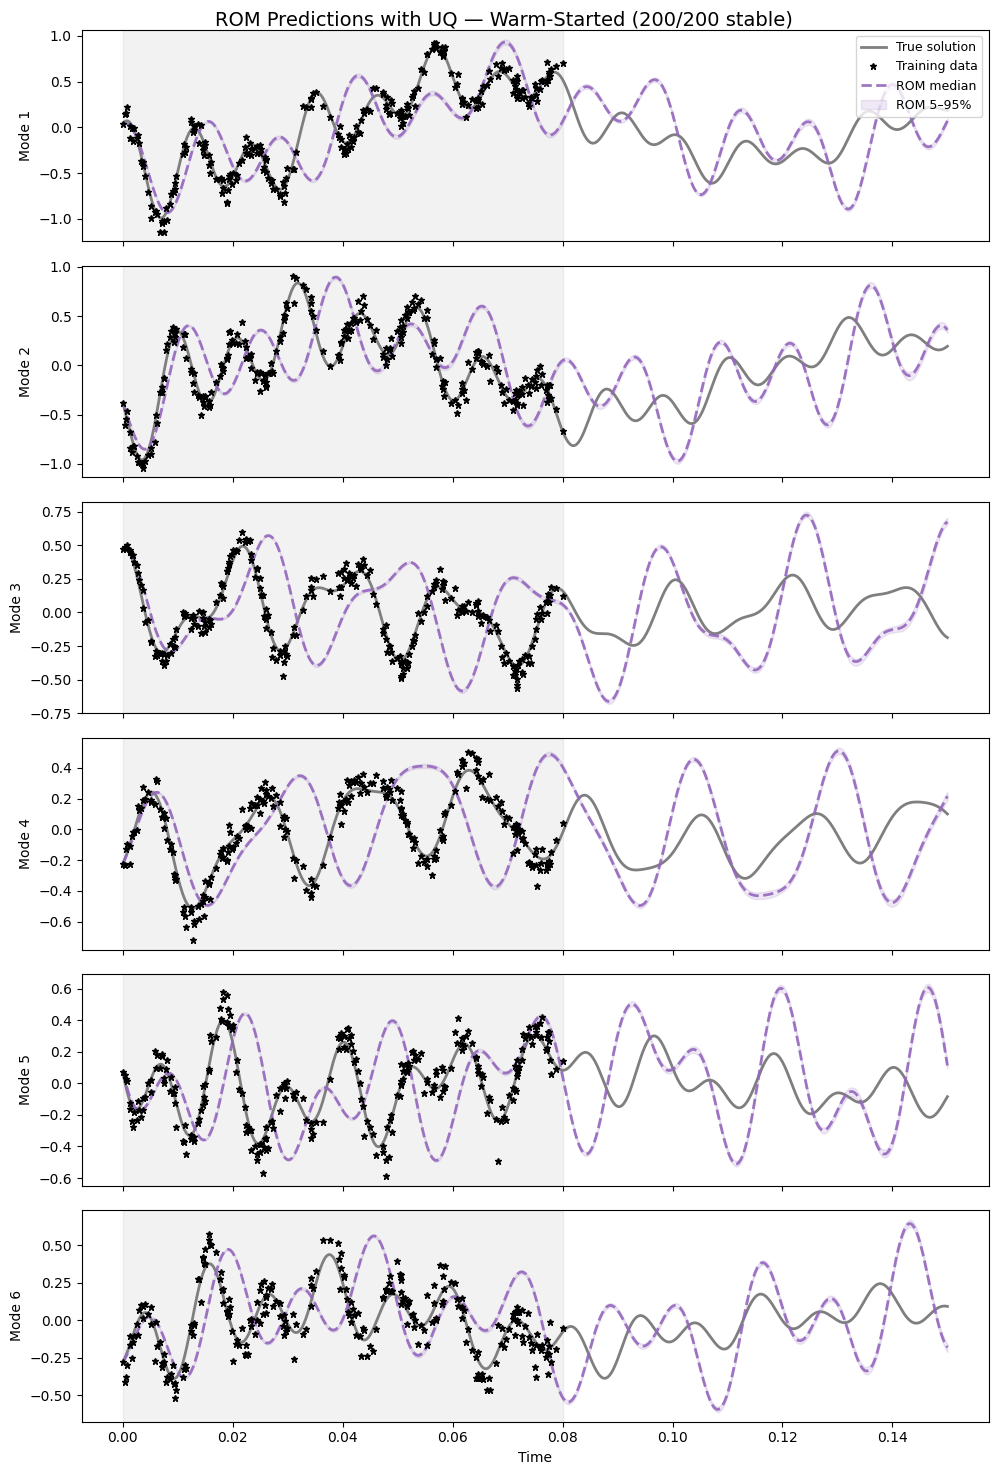

In [36]:
Os, Xs, rom_solves = generate_rom_predictions(
    samples=samples, rom=rom,
    snapshots_compressed=snapshots_comp_sampled,
    time_eval=time_domain_eval_prediction,
    num_modes=NUM_MODES, num_pulls=200,
    input_func=None,
    data_scaler=data_scaler if USE_SCALED_DATA else None,
    ivp_method=IVP_METHOD,
)
n_stable = len(rom_solves)
print(f"Operator samples: {len(Os)}, Stable solves: {n_stable}")

fig, axes = plt.subplots(NUM_MODES, 1, figsize=(10, 2.5 * NUM_MODES), sharex=True)
if NUM_MODES == 1:
    axes = [axes]

for i in range(NUM_MODES):
    ax = axes[i]
    ax.axvspan(TRAINING_SPAN[0], TRAINING_SPAN[1], color='gray', alpha=0.10, zorder=0)
    ax.plot(time_domain_full, full_states_compressed[i],
            color='tab:gray', lw=2, label='True solution')
    ax.plot(time_sampled, snapshots_comp_sampled[i],
            'k*', ms=5, label='Training data', zorder=5)

    if n_stable > 0:
        rom_arr = np.array(rom_solves)
        ax.plot(time_domain_eval_prediction, np.median(rom_arr[:, i, :], axis=0),
                color='tab:purple', linestyle='--', alpha=0.9, lw=2, label='ROM median')
        ax.fill_between(
            time_domain_eval_prediction,
            np.percentile(rom_arr[:, i, :], 5, axis=0),
            np.percentile(rom_arr[:, i, :], 95, axis=0),
            color='tab:purple', alpha=0.15, label='ROM 5–95%')

    ax.set_ylabel(f'Mode {i+1}')
    if i == 0:
        ax.legend(loc='upper right', fontsize=9)

axes[-1].set_xlabel('Time')
fig.suptitle(f'ROM Predictions with UQ — Warm-Started ({n_stable}/{len(Os)} stable)', fontsize=14)
fig.tight_layout()
plt.show()

## 7. Summary

In [37]:
print("=" * 60)
print("EXPERIMENT SUMMARY: Euler — Warm-Started Joint Bayesian")
print("=" * 60)
print(f"Operators: {OPERATORS}")
print(f"Modes: {NUM_MODES}")
print(f"Training span: [{TRAINING_SPAN[0]}, {TRAINING_SPAN[1]}]")
print(f"Prediction span: [{PREDICTION_SPAN[0]}, {PREDICTION_SPAN[1]}]")
print(f"Scaling: {'enabled' if USE_SCALED_DATA else 'disabled'}")
print(f"Gamma (operator): {GAMMA}")
print(f"Gamma2 (ODE): {GAMMA2}")
print(f"Guide: {GUIDE.__name__}")
print(f"SVI steps: {NUM_SVI_STEPS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"\nWarm Start:")
print(f"  MLE GP hyperparams: ✓")
print(f"  LS Operator: ✓ (shape {O_init.shape})")
print(f"\nInferred GP Hyperparameters (SVI median vs MLE):")
for i in range(NUM_MODES):
    print(f"  Mode {i}: ℓ={Ls[i]:.4f} (MLE: {mle_Ls[i]:.4f}), "
          f"σ²={Vs[i]:.4f} (MLE: {mle_Vs[i]:.4f}), "
          f"ν={Ns[i]:.6f} (MLE: {mle_Ns[i]:.6f})")
print(f"\nOperator samples: {len(Os)}")
print(f"Stable ROM solves: {len(rom_solves)}")
print(f"Algorithm runtime: {algo_time:.1f}s ({algo_time/60:.1f}min)")

EXPERIMENT SUMMARY: Euler — Warm-Started Joint Bayesian
Operators: cAH
Modes: 6
Training span: [0, 0.08]
Prediction span: [0, 0.15]
Scaling: disabled
Gamma (operator): 0.5
Gamma2 (ODE): 10.0
Guide: AutoNormal
SVI steps: 10000
Learning rate: 0.001

Warm Start:
  MLE GP hyperparams: ✓
  LS Operator: ✓ (shape (6, 28))

Inferred GP Hyperparameters (SVI median vs MLE):
  Mode 0: ℓ=0.0041 (MLE: 0.0042), σ²=0.0196 (MLE: 0.3300), ν=0.019260 (MLE: 0.005277)
  Mode 1: ℓ=0.0048 (MLE: 0.0039), σ²=0.0687 (MLE: 0.2913), ν=0.020635 (MLE: 0.005780)
  Mode 2: ℓ=0.0039 (MLE: 0.0040), σ²=0.0203 (MLE: 0.1096), ν=0.014725 (MLE: 0.002668)
  Mode 3: ℓ=0.0039 (MLE: 0.0046), σ²=0.0169 (MLE: 0.1086), ν=0.012207 (MLE: 0.003239)
  Mode 4: ℓ=0.0022 (MLE: 0.0036), σ²=0.0542 (MLE: 0.1213), ν=0.011143 (MLE: 0.004204)
  Mode 5: ℓ=0.0049 (MLE: 0.0034), σ²=0.0556 (MLE: 0.0882), ν=0.012327 (MLE: 0.006151)

Operator samples: 200
Stable ROM solves: 200
Algorithm runtime: 232.0s (3.9min)
